#Importing all the required modules

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
table=pd.read_csv("loan.csv",low_memory=False)
table.head()
table.shape


(2740, 111)

In [ ]:
#checking the Table
table.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
#checking if there are values that are not empty

table.isnull().sum()


,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
tax_liens,1
tot_hi_cred_lim,2740
total_bal_ex_mort,2740
total_bc_limit,2740


##WE ARE DROPPING COLUMNS WHICH ARE NOT REQUIRED FOR OUR ANALYSIS AND HAVE NULL VALUES

In [ ]:

table.drop(columns=table.columns[-58:,],inplace=True)

In [ ]:
table.drop(columns=['mths_since_last_major_derog','next_pymnt_d'],inplace=True)

In [ ]:
table.dropna(subset=['last_credit_pull_d','collections_12_mths_ex_med','revol_util','last_pymnt_d','emp_length','home_ownership'],inplace=True)

In [ ]:
table.loc[table.dti<=0,'dti']=None
table.dti.dropna(inplace=True)

In [ ]:
table.dtypes


,0
id,int64
member_id,int64
loan_amnt,int64
funded_amnt,int64
funded_amnt_inv,float64
term,object
int_rate,object
installment,float64
grade,object
sub_grade,object


###Converting all the Columns to correct data types and removing symbols and make format correct

In [ ]:
table['earliest_cr_line']=pd.to_datetime(table['earliest_cr_line'], format='%b-%y')
table['issue_d']=pd.to_datetime(table['issue_d'], format='%b-%y')
table['last_pymnt_d']=pd.to_datetime(table['last_pymnt_d'], format='%b-%y')
table['last_credit_pull_d']=pd.to_datetime(table['last_credit_pull_d'], format='%b-%y')

In [ ]:
table['revol_util']=table.revol_util.astype(str).str.replace('%','')
table['int_rate']=table.int_rate.astype(str).str.replace('%','')

In [ ]:
table['revol_util']=pd.to_numeric(table['revol_util'])
table['int_rate']=pd.to_numeric(table.int_rate)

In [ ]:
table['term']=table.term.str.replace('months','')

In [ ]:
table['term']=pd.to_numeric(table.term)

In [ ]:
table['is_defaulted'] = table['loan_status'].apply(lambda x: 1 if x == ('Charged Off') else 0)

In [ ]:
#Checking our table to ensure everything
table.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,is_defaulted
0,1077501,1296599,5000,5000,4975.0,36,10.65,162.87,B,B2,...,0.00,0.00,0.00,2015-01-01,171.62,2016-05-01,0,1,INDIVIDUAL,0
1,1077430,1314167,2500,2500,2500.0,60,15.27,59.83,C,C4,...,0.00,117.08,1.11,2013-04-01,119.66,2013-09-01,0,1,INDIVIDUAL,1
2,1077175,1313524,2400,2400,2400.0,36,15.96,84.33,C,C5,...,0.00,0.00,0.00,2014-06-01,649.91,2016-05-01,0,1,INDIVIDUAL,0
3,1076863,1277178,10000,10000,10000.0,36,13.49,339.31,C,C1,...,16.97,0.00,0.00,2015-01-01,357.48,2016-04-01,0,1,INDIVIDUAL,0
4,1075358,1311748,3000,3000,3000.0,60,12.69,67.79,B,B5,...,0.00,0.00,0.00,2016-05-01,67.79,2016-05-01,0,1,INDIVIDUAL,0


## **Section 1 : Data quality**

Missing values plot

<Axes: ylabel='None'>

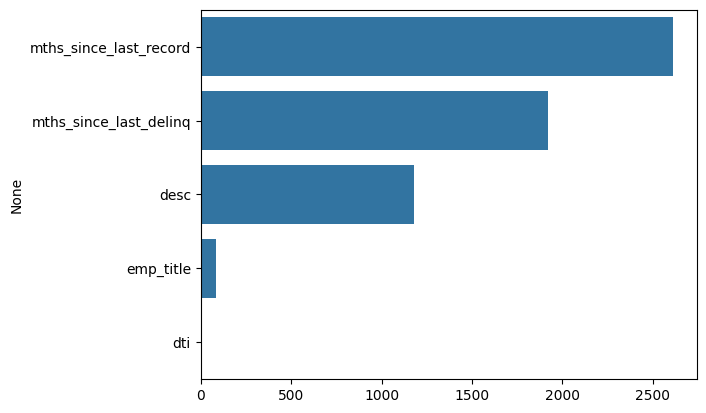

In [ ]:
missing = table.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

sns.barplot(
    x=missing.values,
    y=missing.index
)

Observation: Missing values are concentrated in a small subset of features.

## **Section 2: Outlier Analysis**

<Axes: xlabel='annual_inc'>

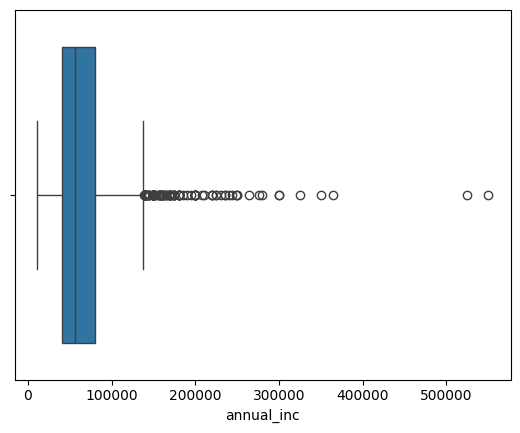

In [ ]:
sns.boxplot(
    x=table['annual_inc']
)

Observation: Annual income contains several extreme high-income borrowers.

<Axes: xlabel='loan_amnt'>

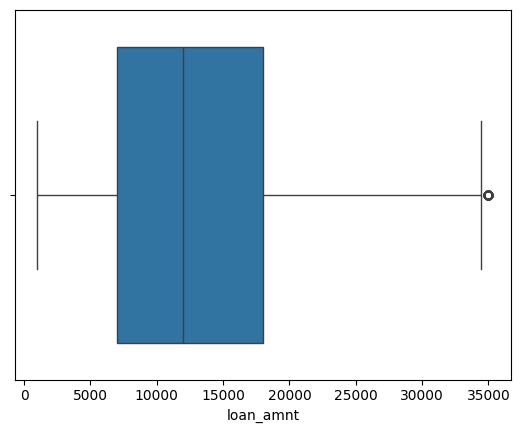

In [ ]:
sns.boxplot(
    x=table['loan_amnt']
)

Observation: Loan amount distribution contains a few unusually large loans.


# **Section 3: Univariate Analysis**

<Axes: xlabel='loan_amnt', ylabel='Count'>

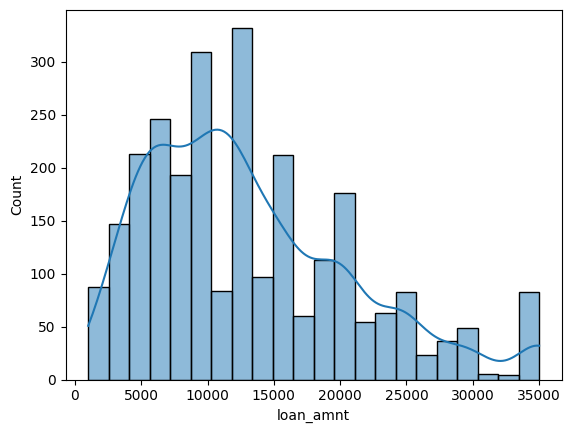

In [ ]:
#Loan Amount Distribution
sns.histplot(
    table['loan_amnt'],
    kde=True
)

Observation: Most loans are concentrated in lower loan amount ranges.


<Axes: xlabel='int_rate', ylabel='Count'>

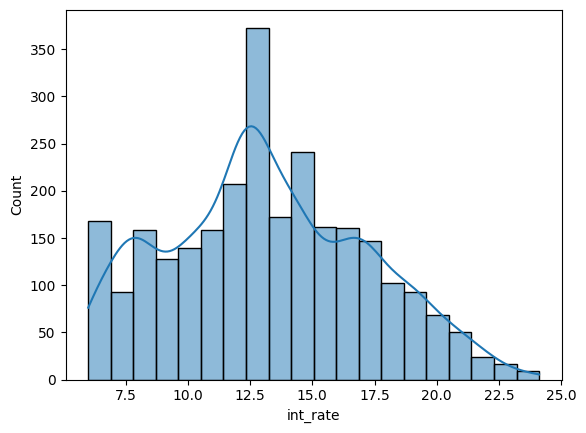

In [ ]:
#Interest Rate Distribution
sns.histplot(
    table['int_rate'],
    kde=True
)

Observation: Interest rates are clustered around a moderate range.


<Axes: ylabel='purpose'>

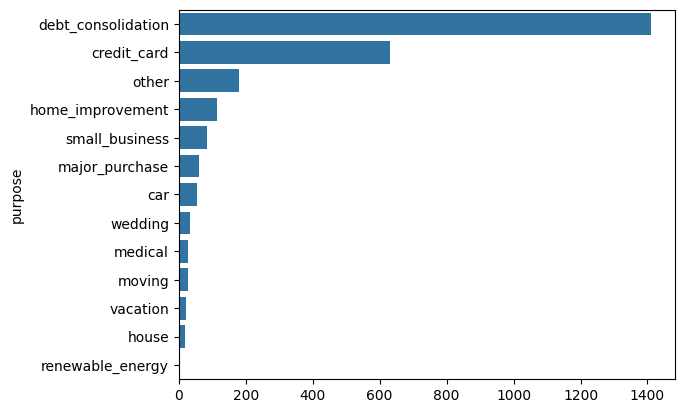

In [ ]:
#Loan Purpose Distribution
purpose_counts = table['purpose'].value_counts()

sns.barplot(
    x=purpose_counts.values,
    y=purpose_counts.index
)

Observation: Debt consolidation dominates loan demand.


<Axes: xlabel='grade', ylabel='count'>

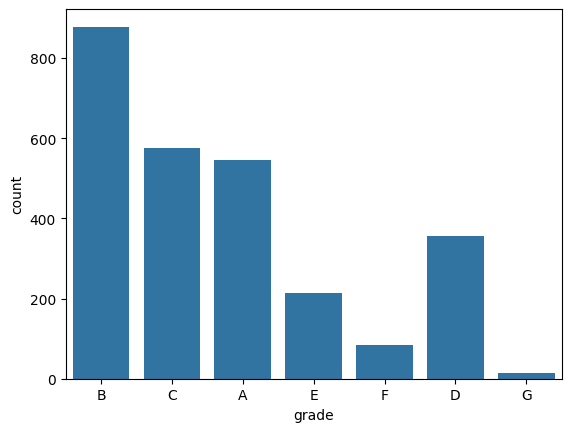

In [ ]:
#Loan Grade Distribution
sns.countplot(
    data=table,
    x='grade'
)

Observation: Most issued loans belong to middle credit grades.

# **Section 4: Default Risk Analysis**

<Axes: xlabel='loan_status', ylabel='int_rate'>

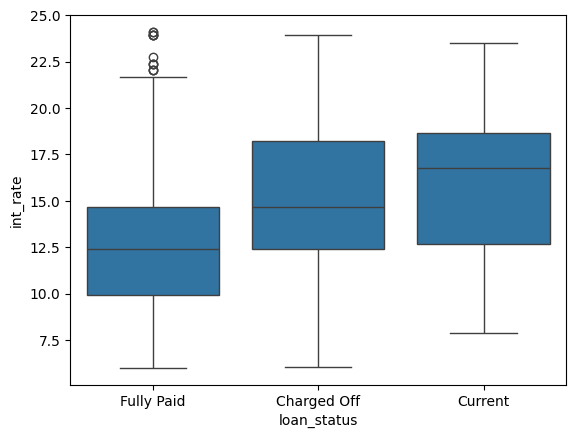

In [ ]:
#Grade vs Loan Status
sns.boxplot(
    data=table,
    x='loan_status',
    y='int_rate'
)

Observation: Defaulted loans generally have higher interest rates.

<Axes: xlabel='count', ylabel='purpose'>

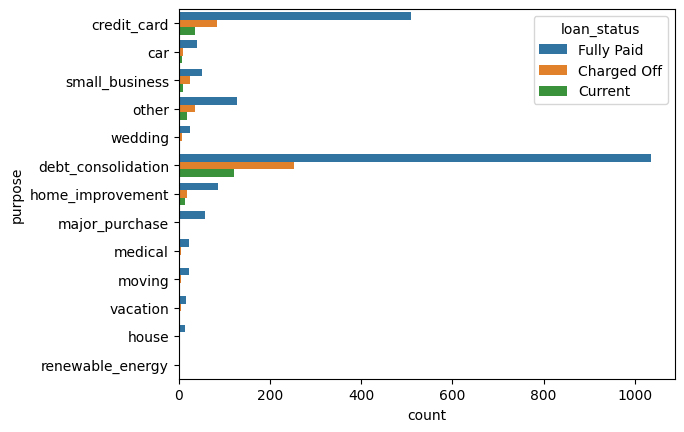

In [ ]:
#Purpose vs Loan Status
sns.countplot(
    data=table,
    y='purpose',
    hue='loan_status'
)

Observation: Certain loan purposes contribute disproportionately to defaults.

# **Section 5: Correlation Analysis**

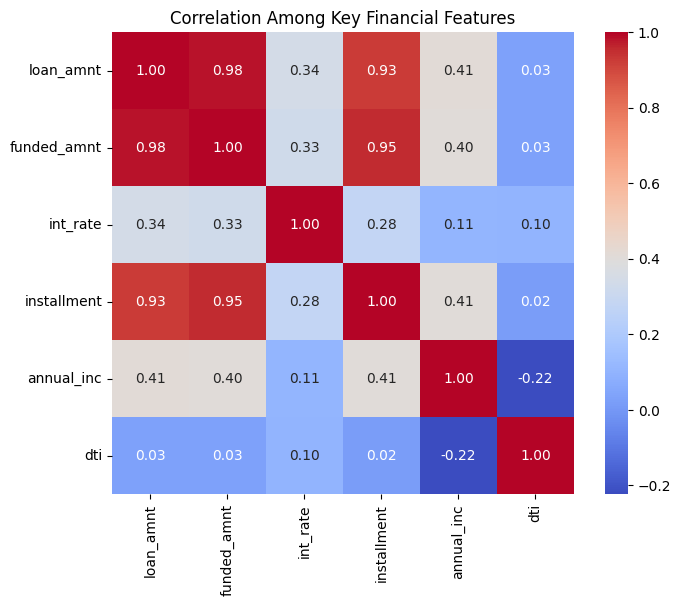

In [ ]:
cols = [
    'loan_amnt',
    'funded_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti'
]

corr = table[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    square=True,
    fmt='.2f'
)

plt.title('Correlation Among Key Financial Features')
plt.show()

The analysis indicates that loan defaults are primarily associated with higher interest rates, lower credit grades, and weaker borrower financial profiles. Debt consolidation represents the largest loan category, highlighting a strong demand for debt restructuring. Among the variables analyzed, credit grade and interest rate emerged as the strongest indicators of default risk. Lending Club can reduce future losses by strengthening underwriting standards and focusing additional risk controls on high-risk borrower segments.